In [1]:
import sys, os
# Erzwingt den Hauptpfad
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.db_connect import load_sql, get_engine

In [2]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import text

# Pfad-Setup: Damit Python den 'src'-Ordner findet
sys.path.append(os.path.abspath('..'))
from src.db_connect import get_engine

# Engine erstellen: Die Verbindung zur Datenbank aufbauen
engine = get_engine()

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Daten laden (falls nicht schon im Speicher)
df = pd.read_sql("SELECT * FROM cohort_respiratory", engine)

# Zusammenfassung erstellen
gender_summary = df.groupby('gender').agg(
    Anzahl=('subject_id', 'count'),
    Alter_Schnitt=('age', 'mean'),
    Sterberate_Prozent=('outcome_death', lambda x: x.mean() * 100)
).round(2)

print("Demografie nach Geschlecht:")
display(gender_summary)

Demografie nach Geschlecht:


,Anzahl,Alter_Schnitt,Sterberate_Prozent
gender,,,
F,3471,83.89,29.33
M,4021,73.84,31.41


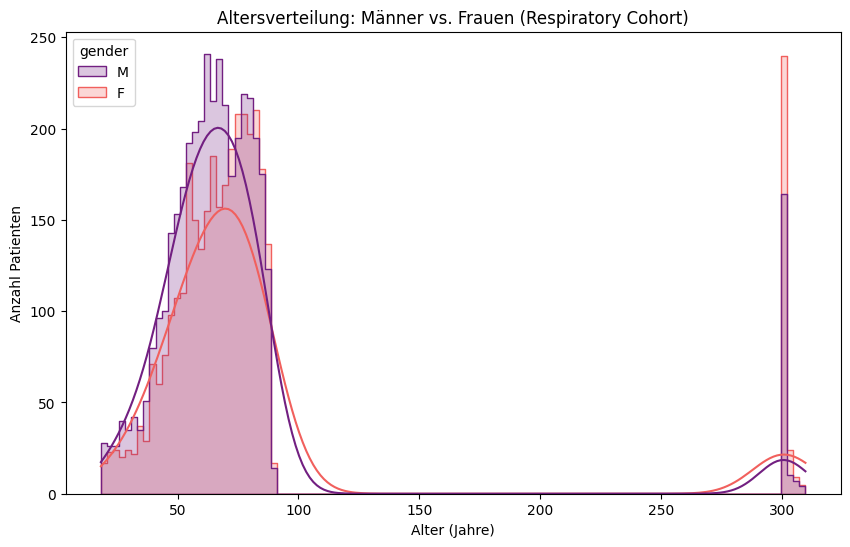

In [4]:
plt.figure(figsize=(10, 6))
# 'hue' definiert die Farben nach Geschlecht, 'element=step' macht es übersichtlicher
sns.histplot(data=df, x='age', hue='gender', kde=True, element="step", palette='magma')

plt.title('Altersverteilung: Männer vs. Frauen (Respiratory Cohort)')
plt.xlabel('Alter (Jahre)')
plt.ylabel('Anzahl Patienten')
plt.show()

Sterberate (%) nach Altersgruppe und Geschlecht:


gender,F,M
age_group,,
18-40,14.77,15.34
41-60,23.40,25.61
61-75,27.71,31.50
75+,36.14,40.74


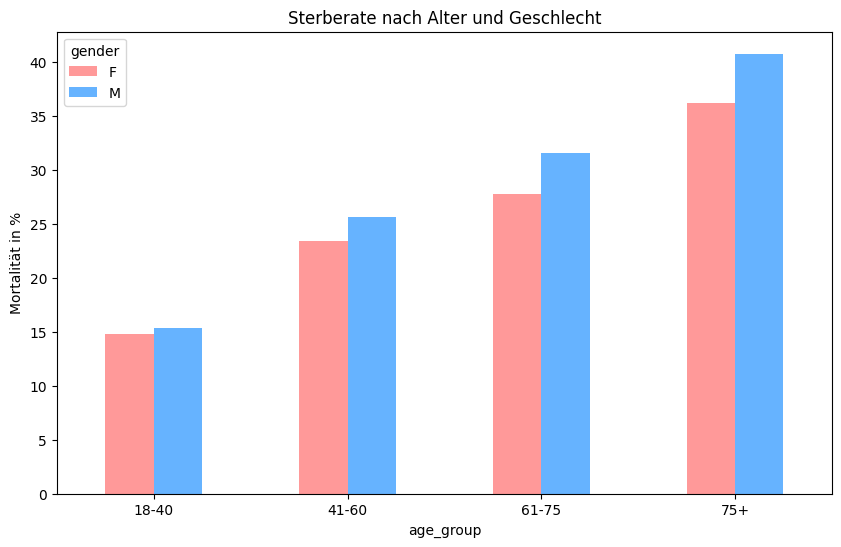

In [5]:
# Altersgruppen erstellen
bins = [18, 40, 60, 75, 100]
labels = ['18-40', '41-60', '61-75', '75+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# Analyse nach Altersgruppe und Geschlecht
age_gender_death = df.groupby(['age_group', 'gender'], observed=False)['outcome_death'].mean().unstack() * 100

print("Sterberate (%) nach Altersgruppe und Geschlecht:")
display(age_gender_death.round(2))

# Visualisierung
age_gender_death.plot(kind='bar', figsize=(10,6), color=['#ff9999','#66b3ff'])
plt.title('Sterberate nach Alter und Geschlecht')
plt.ylabel('Mortalität in %')
plt.xticks(rotation=0)
plt.show()

Sterberate nach Alter und Beatmungsstatus:


,Nicht beatmet (%),Beatmet (%)
age_group,,
18-40,13.33,15.31
41-60,19.57,25.61
61-75,24.02,31.15
75+,39.47,38.06


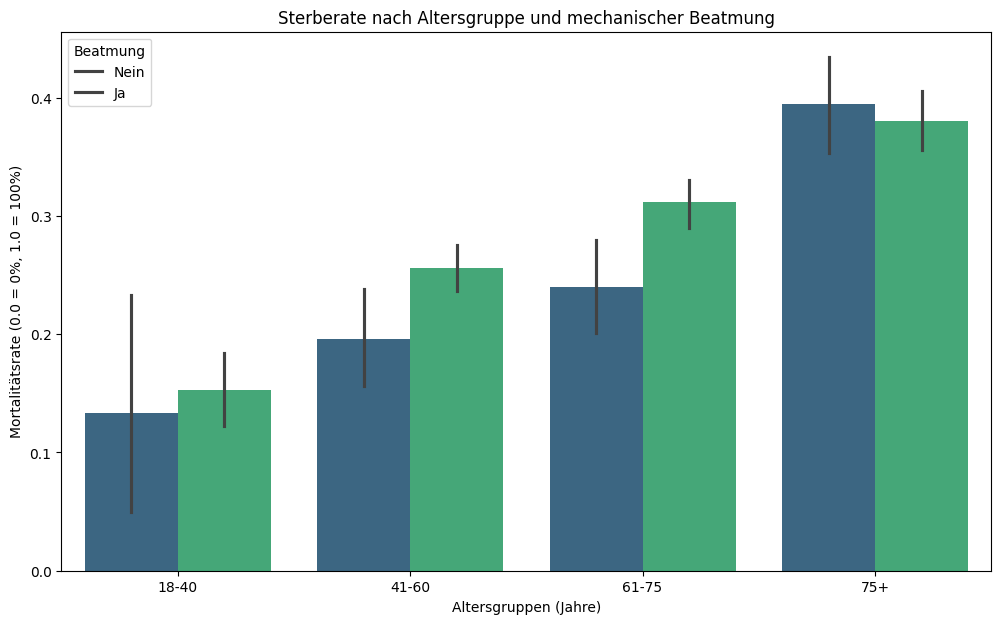

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Daten laden (Stelle sicher, dass 'engine' am Dateianfang definiert wurde)
df = pd.read_sql("SELECT * FROM cohort_respiratory", engine)

# 2. Altersgruppen erstellen (Bins)
# Wir teilen das Alter in sinnvolle medizinische Kategorien ein
bins = [18, 40, 60, 75, 100]
labels = ['18-40', '41-60', '61-75', '75+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# 3. Analyse: Sterberate nach Altersgruppe UND Beatmung
# 'observed=False' verhindert Fehler bei leeren Kategorien
analysis = df.groupby(['age_group', 'intervention_ventilation'], observed=False)['outcome_death'].mean().unstack() * 100
analysis.columns = ['Nicht beatmet (%)', 'Beatmet (%)']

print("Sterberate nach Alter und Beatmungsstatus:")
display(analysis.round(2))

# 4. Visualisierung
plt.figure(figsize=(12, 7))
sns.barplot(data=df, x='age_group', y='outcome_death', hue='intervention_ventilation', palette='viridis')

plt.title('Sterberate nach Altersgruppe und mechanischer Beatmung')
plt.ylabel('Mortalitätsrate (0.0 = 0%, 1.0 = 100%)')
plt.xlabel('Altersgruppen (Jahre)')
plt.legend(title='Beatmung', labels=['Nein', 'Ja'])
plt.show()